# Eigenvectors on a Labrador Image

## Import Libraries

In [1]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

## Load and Preprocess the Image

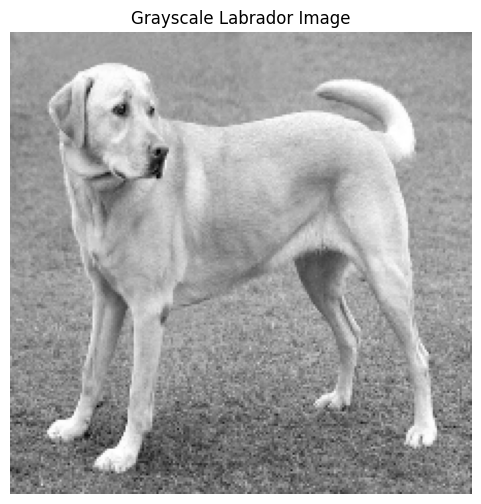

In [2]:
image_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
image_raw = tf.io.read_file(image_path)
image = tf.image.decode_image(image_raw)
image = tf.cast(image, tf.float32)
image = tf.image.resize(image, (224, 224))

image_gray = tf.image.rgb_to_grayscale(image)

# getting a 2D array
image_gray_2d = tf.squeeze(image_gray)

# tensor to array
image_gray_2d_np = image_gray_2d.numpy()

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image_gray_2d_np, cmap='gray')
plt.title('Grayscale Labrador Image')
plt.axis('off')
plt.show()

## Prepare the Image Data for Analysis

In [3]:
# shape
rows, cols = image_gray_2d_np.shape

# combining x, y positions with intensities because we need it for covariance matrix
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
positions = np.column_stack((x.flatten(), y.flatten()))
intensities = image_gray_2d_np.flatten()
data = np.column_stack((positions, intensities))

# covariance matrix - this helps us find patterns in the image
cov_matrix = np.cov(data.T)  # chechk each column is a variable

print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (3, 3)


## Compute Eigenvalues and Eigenvectors

In [4]:
# computing the our heroes - eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = LA.eig(cov_matrix)

# now cheking eigenvalues and eigenvectors are real, if not we will take real parts od that
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# We sort them  because we want to focus on the most important pairs
sorted_eivalues = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_eivalues]
eigenvectors = eigenvectors[:, sorted_eivalues]

# we need only first two for 2D plotting
eigenvectors_2d = eigenvectors[:, :2]

print("top two eigenvalues:", eigenvalues[:2])
print("Top Eigenvectors Shape:", eigenvectors_2d.shape)

top two eigenvalues: [4562.01548394 4181.33333333]
Top Eigenvectors Shape: (3, 2)


## Visualize the Image with Eigenvectors

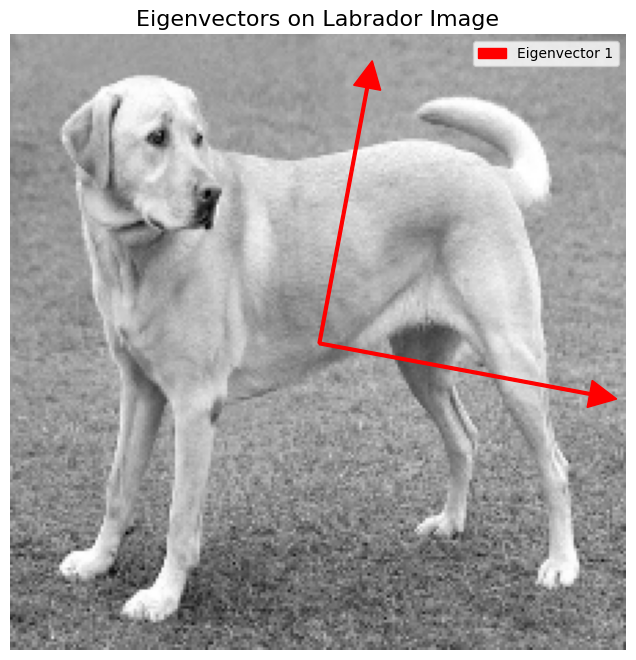

In [5]:
plt.figure(figsize=(8, 8))
plt.imshow(image_gray_2d_np, cmap='gray')

# center of image eigenvectors will originate from there
center = np.array([image_gray_2d_np.shape[1] // 2, image_gray_2d_np.shape[0] // 2])

# for eigenvectors
scale = 100

# Plotting eigenvectors like arrows - these arrows shows the main patterns or maybe directions of image
for i, eigenvector in enumerate(eigenvectors_2d.T):
    norm = np.linalg.norm(eigenvector)
    if norm > 0:
        eigenvector_normalized = eigenvector / norm
        plt.arrow(
            center[0], center[1],
            eigenvector_normalized[0] * scale, eigenvector_normalized[1] * scale,
            color='red', width=1, head_width=10, head_length=10,
            label=f'Eigenvector {i+1}' if i == 0 else ""
        )

plt.title('Eigenvectors on Labrador Image', fontsize=16)
plt.legend()
plt.axis('off')
plt.show()